`conda activate cellcharter`

In [1]:
import anndata as ad
import squidpy as sq
import pandas as pd
import scanpy as sc
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.io
import os
import cell2location

mpl.rcParams["figure.figsize"] = (5, 5)
mpl.rcParams['pdf.fonttype'] = 42

/home/cruiz2/miniconda3/envs/cellcharter/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
adata = sc.read('sp.h5ad')

adata

AnnData object with n_obs × n_vars = 16185 × 15284
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', '_indices', '_scvi_batch', '_scvi_labels', 'AC_like', 'Astrocyte', 'B_cell', 'COP_like', 'Cilia_like', 'Endothelial', 'GB_like', 'GW_like', 'Mono_neutrophil', 'Mural', 'Neuron', 'OPC', 'OPC_like', 'Oligodendrocyte', 'RG_like', 'TAM_C1Q', 'TAM_IL1B', 'TAM_homeostatic', 'TAM_lipid_laden', 'TAM_scavenger', 'TD_like', 'T_cell', 'Tri_IPC_like', 'nIPC_like', 'total RNA counts', 'Total cell abundance (sum_f w_sf)', 'RNA detection sensitivity (y_s)', 'mean_nUMI_factorsfact_0', 'mean_nUMI_factorsfact_1', 'mean_nUMI_factorsfact_2', 'mean_nUMI_factorsfact_3', 'mean_nUMI_factorsfact_4', 'mean_nUMI_factorsfact_5', 'mean_nUMI_factorsfact_6', 'mean_nUMI_factorsfact_7', 'mean_nUMI_factorsf

In [3]:
# select one slide
from cell2location.utils import select_slide

# Define the samples that need modifications and corresponding library_id
sample_library_dict = {
    'BT01_192_core_HE': 'BT01_192_core_HE/outs/',
    'VUMC_17_pons_HE': 'VUMC_17_pons_HE/outs/',
    'VUMC_11_pons_HE': 'VUMC_11_pons_HE/outs/'
}

from scanpy.tools import score_genes
import matplotlib.pyplot as plt
import numpy as np

# Define the list of genes
genes_of_interest = [
    'AC114730.3', 'ACAT2', 'ACTB', 'ANAPC11', 'ANXA2', 'AP2S1', 'ASCL1', 'ASPM', 'ATF3', 'ATP1B3',
    'AURKA', 'AURKAIP1', 'AURKB', 'B2M', 'BCAN', 'BCL7C', 'BIRC5', 'BTG1', 'BUB1', 'BUD31', 'CALM1',
    'CALM2', 'CASC5', 'CCDC109B', 'CCNA2', 'CDCA3', 'CDK1', 'CDKN3', 'CENPA', 'CENPF', 'CENPK',
    'CFL1', 'CHCHD2', 'CHCHD3', 'CKAP2', 'CKS1B', 'CLIC1', 'CLU', 'CNN3', 'COPRS', 'COX5A', 'COX8A',
    'CRYAB', 'CTNNAL1', 'CYR61', 'DCX', 'DLGAP5', 'DLL1', 'DLL3', 'DNAJB1', 'DNPH1', 'DTYMK', 'ECI1',
    'EEF1B2', 'ETFB', 'ETV1', 'FAM64A', 'FAM83D', 'FBXO5', 'FDPS', 'FIBP', 'GAPDH', 'GFAP', 'GNB2',
    'GPX4', 'GSTP1', 'GTSE1', 'H2AFZ', 'HES6', 'HINT1', 'HINT2', 'HIST1H4C', 'HJURP', 'HMGB2', 'HOPX',
    'ITGB1BP1', 'KCNQ1OT1', 'KIAA0101', 'KIF20A', 'KIF23', 'KIF2C', 'KIFC1', 'KPNA2', 'LINC00152',
    'LMNB1', 'LRRN1', 'LSMD1', 'MAD2L1', 'MALAT1', 'MANF', 'MARCKSL1', 'MEA1', 'MFNG', 'MIR4435-1HG',
    'MKI67', 'MRPL37', 'MT-ND3', 'MT2A', 'MXD3', 'MYC', 'MZT2B', 'NCAPG', 'NDC80', 'NDUFA4', 'NDUFA6',
    'NDUFS8', 'NEK2', 'NEU4', 'NGFRAP1', 'NMB', 'NUF2', 'NUSAP1', 'OLIG1', 'PBK', 'PCOLCE', 'PFN1',
    'PHF19', 'PHPT1', 'PKM', 'POLR2I', 'PPIA', 'PRC1', 'PRR24', 'PSMA7', 'PSMB3', 'PSME2', 'PTN',
    'PTTG1', 'PXMP2', 'RACGAP1', 'RBX1', 'RDX', 'RRM2', 'SGOL1', 'SGOL2', 'SHD', 'SHMT2', 'SIVA1',
    'SLC25A5', 'SMC4', 'SOCS3', 'SOX4', 'SPARC', 'SPC25', 'SSBP4', 'STK17A', 'TAGLN2', 'TCF12',
    'TCTEX1D2', 'TECR', 'TK1', 'TMEM147', 'TMEM54', 'TNFRSF12A', 'TNK2', 'TOP2A', 'TPI1', 'TPX2',
    'TUBA1B', 'TUBA1C', 'TUBB2A', 'TUBB6', 'UBE2C', 'UBE2T', 'UQCC2', 'UQCR10', 'UQCRC1', 'UQCRQ',
    'VIM', 'VMP1', 'ZFP36', 'ZWINT'
]

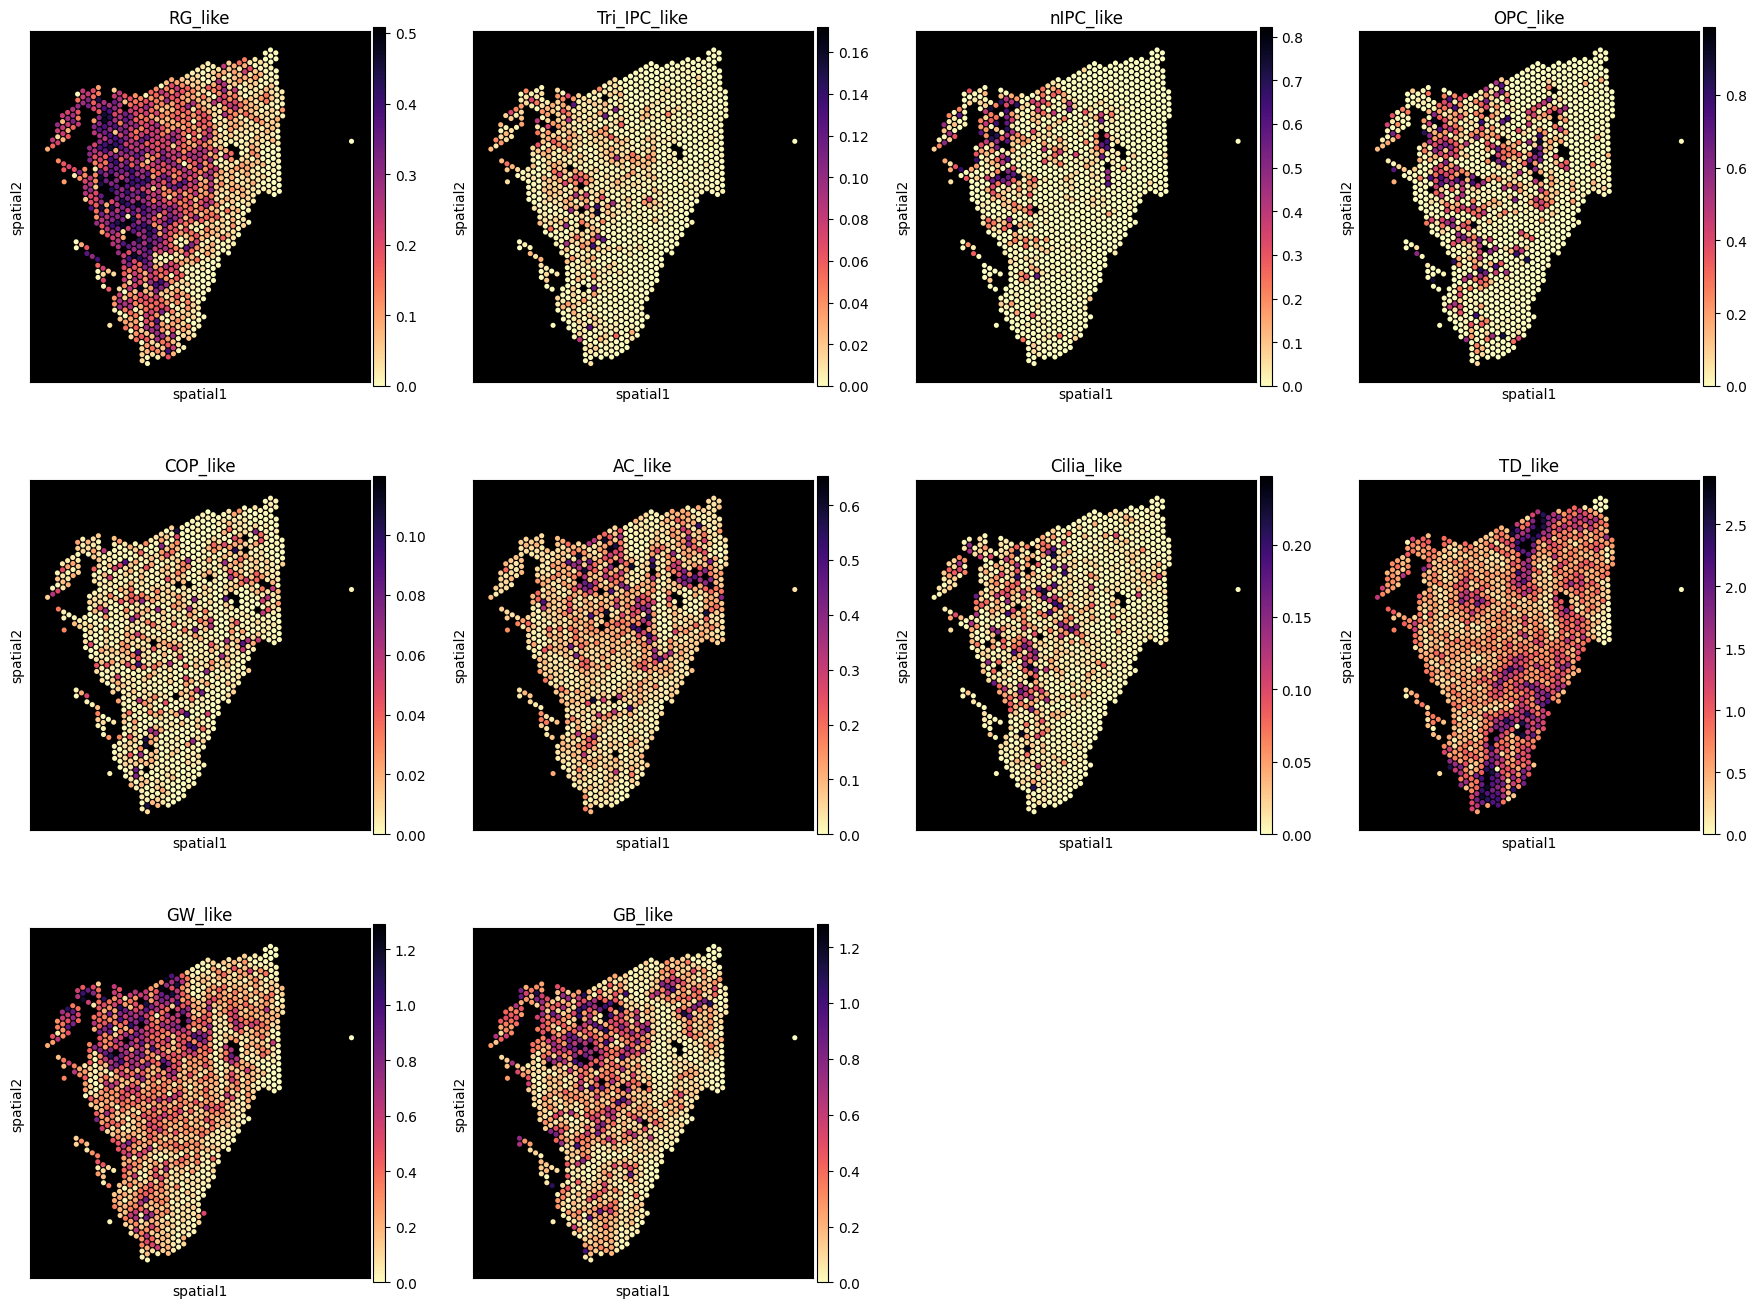

       'KIAA0101', 'LINC00152', 'LSMD1', 'MALAT1', 'MIR4435-1HG', 'NGFRAP1',
       'PRR24', 'SGOL1', 'SGOL2'],
      dtype='object')


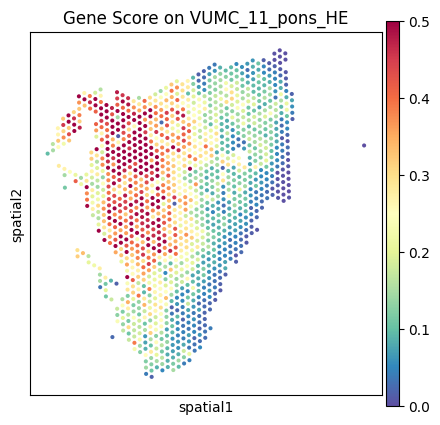

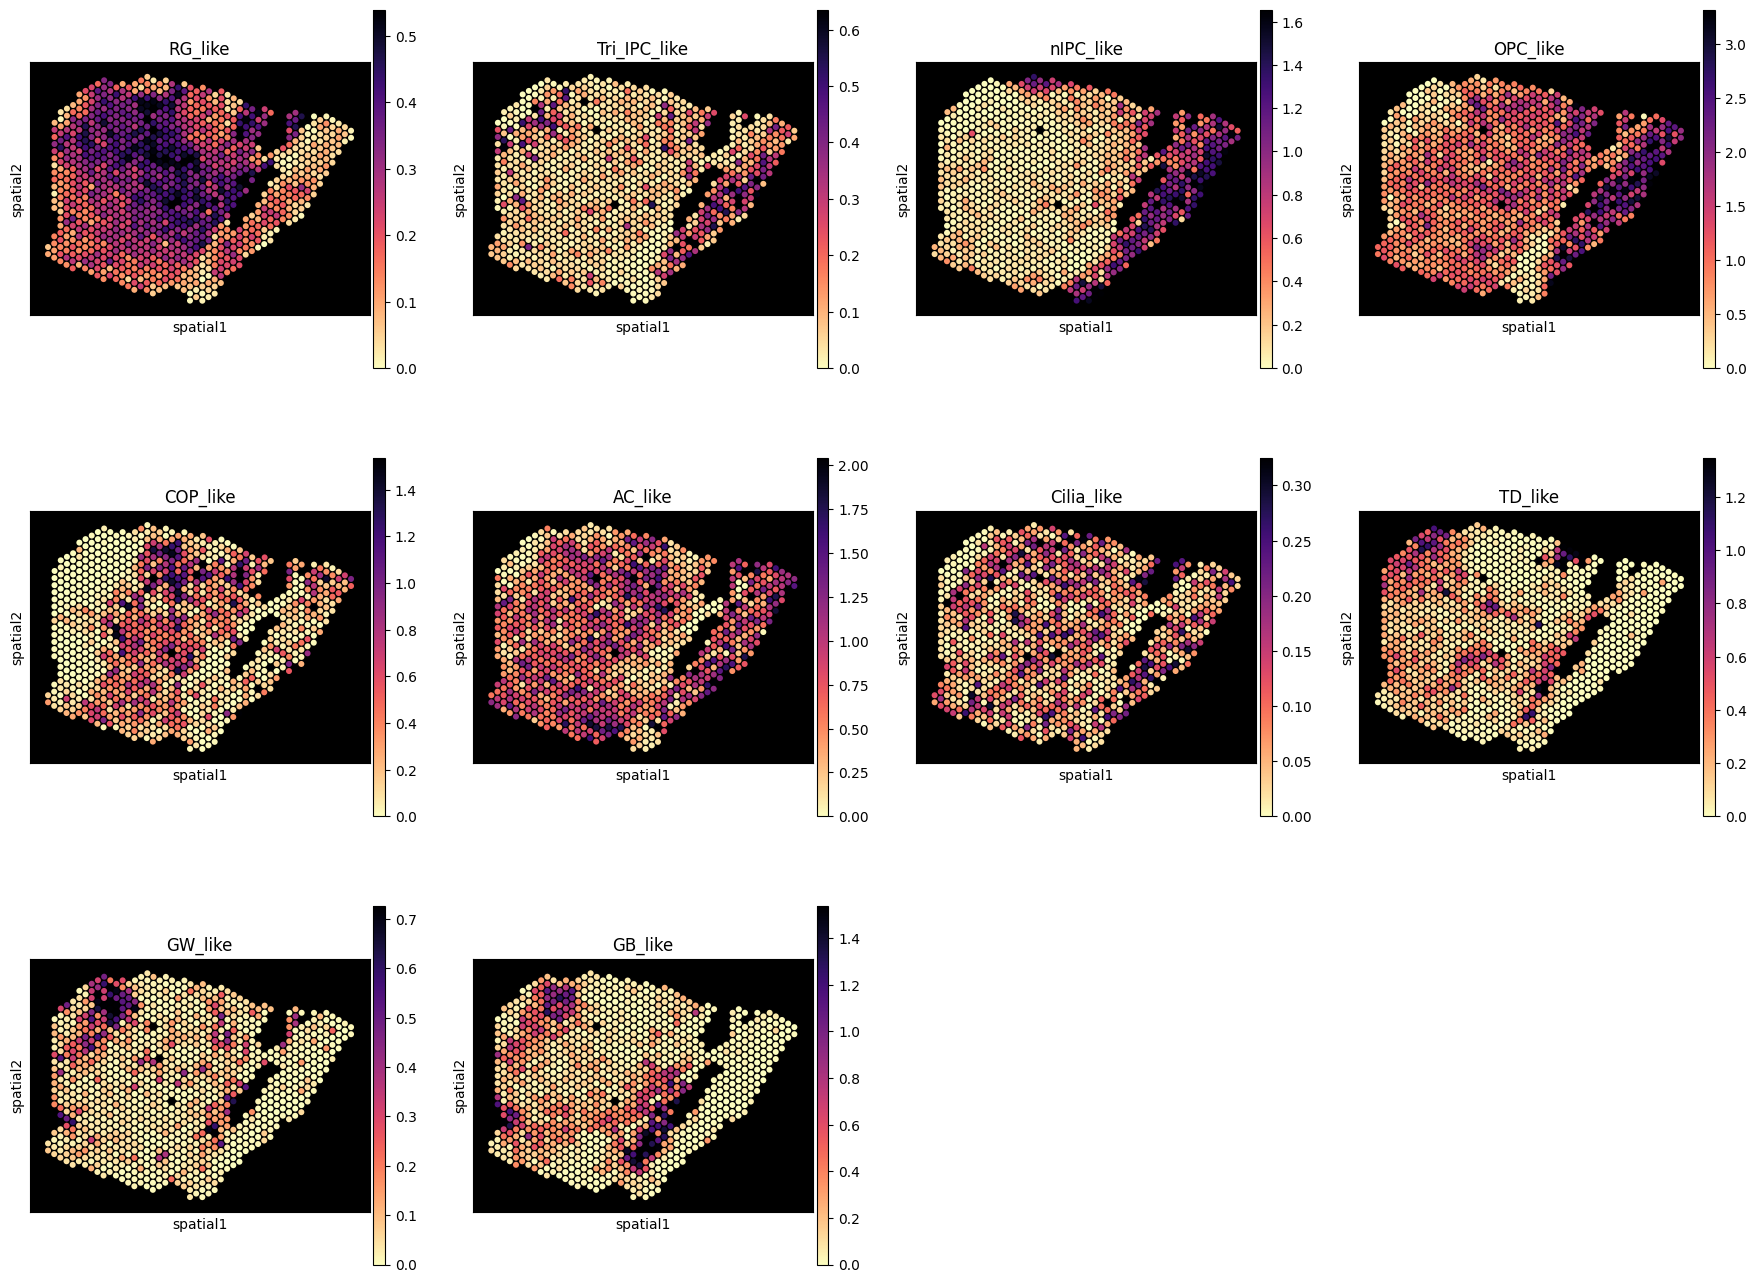

       'KIAA0101', 'LINC00152', 'LSMD1', 'MALAT1', 'MIR4435-1HG', 'NGFRAP1',
       'PRR24', 'SGOL1', 'SGOL2'],
      dtype='object')


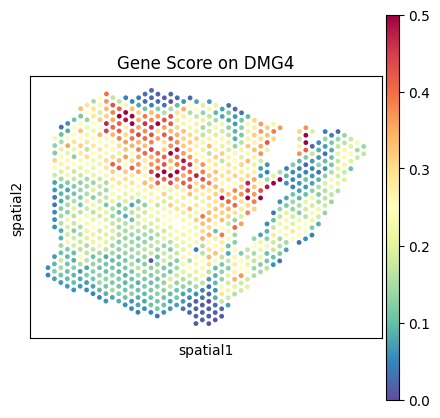

In [11]:
# Define the samples that need modifications and corresponding library_id
sample_library_dict = {
    'BT01_192_core_HE': 'BT01_192_core_HE/outs/',
    'VUMC_17_pons_HE': 'VUMC_17_pons_HE/outs/',
    'VUMC_11_pons_HE': 'VUMC_11_pons_HE/outs/'
}

samples_to_plot= ['VUMC_11_pons_HE', 'DMG4']
# Loop through all unique samples in adata.obs['sample']
for sample in samples_to_plot:
    # Select the slide for the current sample
    slide = select_slide(adata, sample)
    
    # If the sample is in the dictionary, apply the necessary modifications
    if sample in sample_library_dict:
        library_id = sample_library_dict[sample]
        spatial_key = "spatial"
        slide.uns['spatial_slide'] = slide.uns[spatial_key]  # Backup original spatial info
        slide.uns[spatial_key] = {library_id: {}}  # Set up the new spatial dictionary
        slide.uns[spatial_key][library_id] = slide.uns['spatial_slide'][sample]["outs"]  # Update with correct library_id

           # plot in spatial coordinates
    with mpl.rc_context({'axes.facecolor':  'black',
                             'figure.figsize': [4.5, 5]}):
        
        sc.pl.spatial(slide, cmap='magma_r',
                              # show first 8 cell types
                              color=['RG_like', 'Tri_IPC_like','nIPC_like','OPC_like',
            'COP_like','AC_like','Cilia_like','TD_like','GW_like','GB_like'],
                              ncols=4, size=1.3,
                              # img_key='hires',
                              # limit color scale at 99.2% quantile of cell abundance
                              vmin=0, vmax='p99.2',
                          alpha_img=0, 
                      # save=f'figures/cell_abundances_{sample}.pdf'
                             )
         # Score the genes for the current slide
    score_genes(
        slide, 
        gene_list=genes_of_interest, 
        score_name='gene_score'
    )
    
    # Normalize the gene scores for better visualization
    slide.obs['gene_score_norm'] = (
        slide.obs['gene_score'] - slide.obs['gene_score'].min()
    ) / (
        slide.obs['gene_score'].max() - slide.obs['gene_score'].min()
    )
    
    # Plot the spatial data with the gene score
    sc.pl.spatial(
        slide,
        color='gene_score_norm',
        cmap='Spectral_r',  # Use 'Spectral' colormap or replace with your preferred colormap
        title=f'Gene Score on {sample}',
        vmax=0.5,
        alpha_img=0,
         # save=f'figures/invasivity_score_{sample}.pdf'
    )


In [ ]:
import matplotlib.colors as mcolors
# Define the clusters and the corresponding colors
clusters = [
    'RG_like', 'Tri_IPC_like', 'nIPC_like', 'OPC_like', 'COP_like',
    'AC_like', 'Cilia_like', 'TD_like', 'GW_like', 'GB_like',
    'Oligodendrocyte',
    # 'Astrocyte', 'Neuron', 'OPC',
    'Mono_neutrophil', 'TAM_C1Q', 'TAM_lipid_laden', 'TAM_scavenger',
    'TAM_IL1B', 'TAM_homeostatic', 'T_cell', 'B_cell', 
    'Endothelial', 'Mural'
]

# Reorder the categories
adata_anno.obs['cell2loc_anno'] = adata_anno.obs['cell2loc_anno'].astype("category")
adata_anno.obs['cell2loc_anno'] = adata_anno.obs['cell2loc_anno'].cat.reorder_categories(clusters, ordered=True)

colors = [
    '#74150f', '#b26671', '#fdc955', '#c13910', '#f4e5e1', 
    '#caa4ab','#8f7308', '#ba7db3', '#5c2454', '#474747',
    '#bae7c2', 
    # '#a9a8a8', '#bbbdbf','#f2f2f2',
    '#00a69c', '#165884','#7b7dba', '#95bbcd', 
    '#343682', '#26a9e0', '#ec1c24', '#754c28',
    '#217236', '#a24600'
]

# Create a colormap
colormap = mcolors.ListedColormap(colors)

import matplotlib.colors as mcolors
# Define the clusters and the corresponding colors
clusters = [
    'RG_like', 'Tri_IPC_like', 'nIPC_like', 'OPC_like', 'COP_like',
    'AC_like', 'Cilia_like', 'TD_like', 'GW_like', 'GB_like',
    'Oligodendrocyte',
    # 'Astrocyte', 'Neuron', 'OPC',
    'Mono_neutrophil', 'TAM_C1Q', 'TAM_lipid_laden', 'TAM_scavenger',
    'TAM_IL1B', 'TAM_homeostatic', 'T_cell', 'B_cell', 
    'Endothelial', 'Mural'
]

# Reorder the categories
adata_anno.obs['cell2loc_anno'] = adata_anno.obs['cell2loc_anno'].astype("category")
adata_anno.obs['cell2loc_anno'] = adata_anno.obs['cell2loc_anno'].cat.reorder_categories(clusters, ordered=True)

colors = [
    '#74150f', '#b26671', '#fdc955', '#c13910', '#f4e5e1', 
    '#caa4ab','#8f7308', '#ba7db3', '#5c2454', '#474747',
    '#bae7c2', 
    # '#a9a8a8', '#bbbdbf','#f2f2f2',
    '#00a69c', '#165884','#7b7dba', '#95bbcd', 
    '#343682', '#26a9e0', '#ec1c24', '#754c28',
    '#217236', '#a24600'
]

# Create a colormap
colormap = mcolors.ListedColormap(colors)

# Calculate the median score for each enriched cell type
median_scores = (
    final_df.groupby('enriched_cell_type')['gene_score_norm']
    .median()
    .sort_values(ascending=False)
)

# Create an ordered categorical type based on the median scores
final_df['enriched_cell_type'] = pd.Categorical(
    final_df['enriched_cell_type'],
    categories=median_scores.index,
    ordered=True
)

# Define the prefix and modify the clusters list to include it
prefix = 'q05cell_abundance_w_sf_'
clusters = [
    'RG_like', 'Tri_IPC_like', 'nIPC_like', 'OPC_like', 'COP_like',
    'AC_like', 'Cilia_like', 'TD_like', 'GW_like', 'GB_like'
]
clusters_with_prefix = [f"{prefix}{cluster}" for cluster in clusters]

# Define the corresponding colors
colors = [
    '#74150f', '#b26671', '#fdc955', '#c13910', '#f4e5e1', 
    '#caa4ab', '#8f7308', '#ba7db3', '#5c2454', '#474747'
]

# Create a dictionary mapping the prefixed cell types to colors
color_palette = dict(zip(clusters_with_prefix, colors))

# Plot results
plt.figure(figsize=(6, 6))
sns.boxplot(
    data=final_df,
    x='enriched_cell_type',
    y='gene_score_norm',
    palette=color_palette
)
plt.title('Gene Scores vs Enriched Cell Types (Sorted by Median)')
plt.xticks(rotation=90)
plt.ylabel('Gene Score (Normalized)')
plt.xlabel('Enriched Cell Type')
plt.tight_layout()
# plt.savefig('figures/boxplot_invasivity_score_visium.pdf')
plt.show()